In [ ]:
import sys
sys.path.append("..")

import pandas as pd

from autoimmune_analysis.HLA_module import HLA
from autoimmune_analysis import HLA_forest_plot


## Data preparation

### Uploading metadata

In [9]:
metadata = pd.read_csv('..\data\metadata_ifn_predictions.csv')
metadata.head(3)

,SRR,GSE,object,diagnosis,sex,age,ethnicity,RNA_type,treatment,disease_type,country,state_province,continent,ifn_status,Batch_GMM,Batch_GMM_Harmony,Batch_GMM_Harmony_k3,Final_Batch,IFN_Activity_Score,predicted_ifn_status
0,SRR10342368,GSE139350,PBMC,SLE,F,47.0,NaN,polyA,NaN,SLE,China,Hubei,NaN,NaN,1,1,1,1,0.06,Low
1,SRR10342369,GSE139350,PBMC,SLE,F,38.0,NaN,polyA,NaN,SLE,China,Hubei,NaN,NaN,1,1,1,1,0.47,Low
2,SRR10342370,GSE139350,PBMC,H,F,45.0,NaN,polyA,NaN,H,China,Hubei,NaN,NaN,1,0,0,0,0.00,Low


In [10]:
# selecting the necessary metadata
status = metadata[['SRR', 'diagnosis', 'ethnicity', 'country', 'predicted_ifn_status']].copy()
status.rename(columns={'predicted_ifn_status': 'IFN_status'}, inplace=True)

### Uploading arcasHLA results

In [11]:
df = pd.read_csv('..\data\genotypes.tsv', sep='\t')

### Concatenating arcasHLA results with metadata

In [12]:
df.rename(columns={'subject': 'SRR'}, inplace=True)
df = pd.merge(status, df, on='SRR')
df.head(3)

,SRR,diagnosis,ethnicity,country,IFN_status,A1,A2,B1,B2,C1,...,K1,K2,L1,L2,H1,H2,J1,J2,DRB31,DRB32
0,SRR10342368,SLE,NaN,China,Low,A*11:303,A*24:02:01,B*56:01:01,B*56:01:01,C*07:02:01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SRR10342369,SLE,NaN,China,Low,A*01:01:71,A*11:303,B*13:07N,B*13:07N,C*04:01:117,...,NaN,NaN,NaN,NaN,H*02:07:01,H*02:07:01,NaN,NaN,NaN,NaN
2,SRR10342370,H,NaN,China,Low,A*24:02:01,A*30:01:01,B*13:07N,B*13:07N,C*06:02:106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dividing data into ethnic groups

In [13]:
print(f"Ethnicities: {pd.unique(metadata['ethnicity'])}")
print(f"Countries: {pd.unique(metadata['country'])}")

Ethnicities: [nan 'C' 'AA' 'H' 'AS' 'O' 'Tibetan' 'IN']
Countries: ['China' 'Spain' 'USA' 'India' 'United_Kingdom']


In [14]:
df_asia = df[df['country'].isin(['China'])]
df_tibetan = df[df['ethnicity'] == 'Tibetan']
df_india = df[df['ethnicity'] == 'IN']
df_aa = df[df['ethnicity'] == 'AA']

df_hispanic = df.loc[(df['ethnicity'] == 'H') | (df['country'] == 'Spain')]

df_caucasian = df[df['country'].isin(['United_Kingdom', 'USA'])]
df_caucasian = df_caucasian[~df_caucasian['ethnicity'].isin(['AS', 'AA', 'H', 'O'])]

In [15]:
data = {'AA': df_aa, 'AS': df_asia, 'C': df_caucasian, 
        'In': df_india, 'H': df_hispanic, 'T': df_tibetan}

In [16]:
for key, df in data.items():
    df['population'] = key
result_df = pd.concat(data.values(), ignore_index=True)

In [17]:
result_df.pivot_table(index=['diagnosis', 'IFN_status'], columns='population',
                      aggfunc='size', fill_value=0)

population            AA  AS    C   H  In  T
diagnosis IFN_status                        
CLE       High        29   0    9   3   0  0
          Low          5   0   11   1   0  0
H         High         0   0    0   5   2  0
          Low          1  18    4  26   2  5
MS        High         0   0    2   9   0  0
          Low          0   0    1  51   0  0
SLE       High         3   2  126   2   8  0
          Low          7  21   70   6   4  5

The following populations are excluded from further study:

1. AS: too few observations with low interferon status (2)
2. Tibetan: no observations with high interferon status
3. Indian: too few observations

Also, due to the lack of observations with high interferon status among healthy people, they will be excluded from the AA and C populations.

In [18]:
final_df = result_df[result_df['population'].isin(['AA', 'C', 'H'])]

In [19]:
final_df = final_df[~((final_df['diagnosis'] == 'H') & (final_df['population'] != 'H'))]

Final distribution of observations by disease and interferon status in different populations:

In [20]:
final_df.pivot_table(index=['diagnosis', 'IFN_status'], columns='population',
                      aggfunc='size', fill_value=0)

population            AA    C   H
diagnosis IFN_status             
CLE       High        29    9   3
          Low          5   11   1
H         High         0    0   5
          Low          0    0  26
MS        High         0    2   9
          Low          0    1  51
SLE       High         3  126   2
          Low          7   70   6

## Analysis

In [21]:
classic_genes = ['A', 'B', 'C', 
                 'DPA1', 'DPB1', 
                 'DRA', 'DRB1', 'DRB3', 'DRB5'
                 'DQA1', 'DQB1']

In [22]:
import time
cohorts = {}
for population, batch in final_df.groupby('population'):
    print("-------------------------------")
    print(f"Processing {population}-population...")
    print("-------------------------------")
    time.sleep(1)
    cohorts[population] = HLA(batch)
    cohorts[population].count_alleles(classic_genes)
    cohorts[population].fisher_test()
    cohorts[population].chi2_test()

-------------------------------
Processing AA-population...
-------------------------------


2026-05-23 15:20:53.362 | INFO     
PROCESSING CLE-SAMPLES FOR FISHER TEST 

2026-05-23 15:20:53.401 | INFO     
78 alleles were skipped due to low carrier count (< 3):
A*68:01, A*74:01, A*01:01, A*33:03, A*36:01, A*68:02, A*03:36N, A*33:01, A*33:256, A*66:02, B*49:01, B*08:272, B*15:03, B*51:01, B*07:06, B*08:201, B*14:01, B*14:05, B*15:10, B*18:25, B*57:03, B*81:01, B*08:146, B*08:205, B*08:242, B*35:03, B*35:11, B*41:01, B*42:33, B*50:01, B*50:25, B*51:02, B*58:02, B*78:01, C*04:296, C*04:456Q, C*02:02, C*07:112, C*04:262, C*04:480, C*07:06, C*07:18, C*07:19, C*07:783, C*17:38, C*18:01, C*18:03, DPA1*04:02, DPA1*01:04, DPB1*665:01, DPB1*02:01, DPB1*677:01, DPB1*1088:01, DPB1*11:01, DPB1*1332:01N, DPB1*13:01, DPB1*15:01, DPB1*162:01, DPB1*179:01, DPB1*1800:01, DPB1*1889:01, DPB1*18:01, DPB1*49:01, DPB1*519:01, DPB1*81:01, DPB1*849:01, DQB1*05:359, DQB1*06:107, DQB1*06:112N, DQB1*06:114, DQB1*06:352, DRA*01:17, DRB1*13:03, DRB1*11:02, DRB1*12:02, DRB1*13:01, DRB1*13:04, DRB1*15:01 

2

-------------------------------
Processing C-population...
-------------------------------


2026-05-23 15:20:54.873 | INFO     
PROCESSING CLE-SAMPLES FOR FISHER TEST 

2026-05-23 15:20:54.893 | INFO     
47 alleles were skipped due to low carrier count (< 3):
A*11:303, A*01:01, A*01:194, A*01:251, A*03:97, A*11:01, A*24:02, A*31:01, A*33:03, B*07:386N, B*08:270Q, B*08:329Q, B*14:02, B*35:429, B*40:05, B*41:01, B*57:03, B*35:424, B*48:02, C*04:01, C*04:453, C*04:456Q, C*04:296, C*04:468, C*12:342Q, DPA1*02:06, DPB1*05:01, DPB1*11:01, DPB1*39:01, DPB1*02:01, DPB1*135:01, DPB1*04:02, DPB1*190:01, DPB1*677:01, DPB1*71:01, DQB1*06:09, DQB1*05:03, DQB1*06:04, DQB1*06:112N, DQB1*06:335, DRA*01:01, DRA*01:11, DRB1*01:01, DRB1*09:01, DRB1*13:05, DRB1*01:03, DRB1*08:01 

2026-05-23 15:20:54.949 | INFO     
PROCESSING MS-SAMPLES FOR FISHER TEST 

2026-05-23 15:20:54.966 | INFO     
7 alleles were skipped due to low carrier count (< 3):
A*24:454, A*31:01, A*01:01, DPA1*02:01, DPB1*11:01, DQB1*06:535, DQB1*06:114 

2026-05-23 15:20:54.978 | INFO     
PROCESSING SLE-SAMPLES FOR FISHER TES

-------------------------------
Processing H-population...
-------------------------------


2026-05-23 15:20:56.854 | INFO     
PROCESSING CLE-SAMPLES FOR FISHER TEST 

2026-05-23 15:20:56.868 | INFO     
23 alleles were skipped due to low carrier count (< 3):
A*24:02, A*68:01, A*01:01, A*11:303, B*35:15, B*38:01, B*39:05, B*51:01, C*04:01, C*07:02, C*15:02, DPA1*02:01, DPB1*1843:01N, DPB1*11:01, DQB1*06:04, DRA*01:02, DRA*01:01, DRA*01:11, DRB1*13:02, DRB1*08:02, DRB1*11:04, DRB1*14:06, DRB1*16:02 

2026-05-23 15:20:56.880 | INFO     
PROCESSING H-SAMPLES FOR FISHER TEST 

2026-05-23 15:20:56.907 | INFO     
66 alleles were skipped due to low carrier count (< 3):
A*01:241, A*02:87, A*31:01, A*68:02, A*01:281Q, A*01:496, A*02:888, A*24:03, A*24:32, A*24:459, A*68:03, B*08:282, B*14:02, B*51:01, B*57:02, B*27:05, B*40:481N, B*58:01, B*07:381, B*07:386N, B*08:208, B*08:298, B*14:01, B*14:69N, B*18:223, B*37:08, B*40:150, B*52:01, C*01:02, C*04:456Q, C*15:168, C*18:01, C*02:10, C*02:215Q, C*04:189, C*04:296, C*06:02, C*07:639, C*07:744, C*07:940, C*08:23, C*08:73, C*12:181, C*12

In [23]:
cohorts['H'].allele_counts

,diagnosis,gene,allele,IFN_status,carriers,allele_copies,hom,het,n_samples,carrier_freq,allele_freq
0,CLE,A,A*24:02,High,1,2,1,0,3,0.3333,0.3333
1,CLE,A,A*68:01,High,1,2,1,0,3,0.3333,0.3333
2,CLE,A,A*01:01,High,1,1,0,1,3,0.3333,0.1667
3,CLE,A,A*11:303,High,1,1,0,1,3,0.3333,0.1667
4,CLE,A,A*24:02,Low,1,1,0,1,1,1.0000,0.5000
...,...,...,...,...,...,...,...,...,...,...,...
402,SLE,DRB1,DRB1*13:02,Low,1,1,0,1,6,0.1667,0.0833
403,SLE,DRB1,DRB1*13:208,Low,1,1,0,1,6,0.1667,0.0833
404,SLE,DRB1,DRB1*13:372,Low,1,1,0,1,6,0.1667,0.0833
405,SLE,DRB1,DRB1*15:03,Low,1,1,0,1,6,0.1667,0.0833


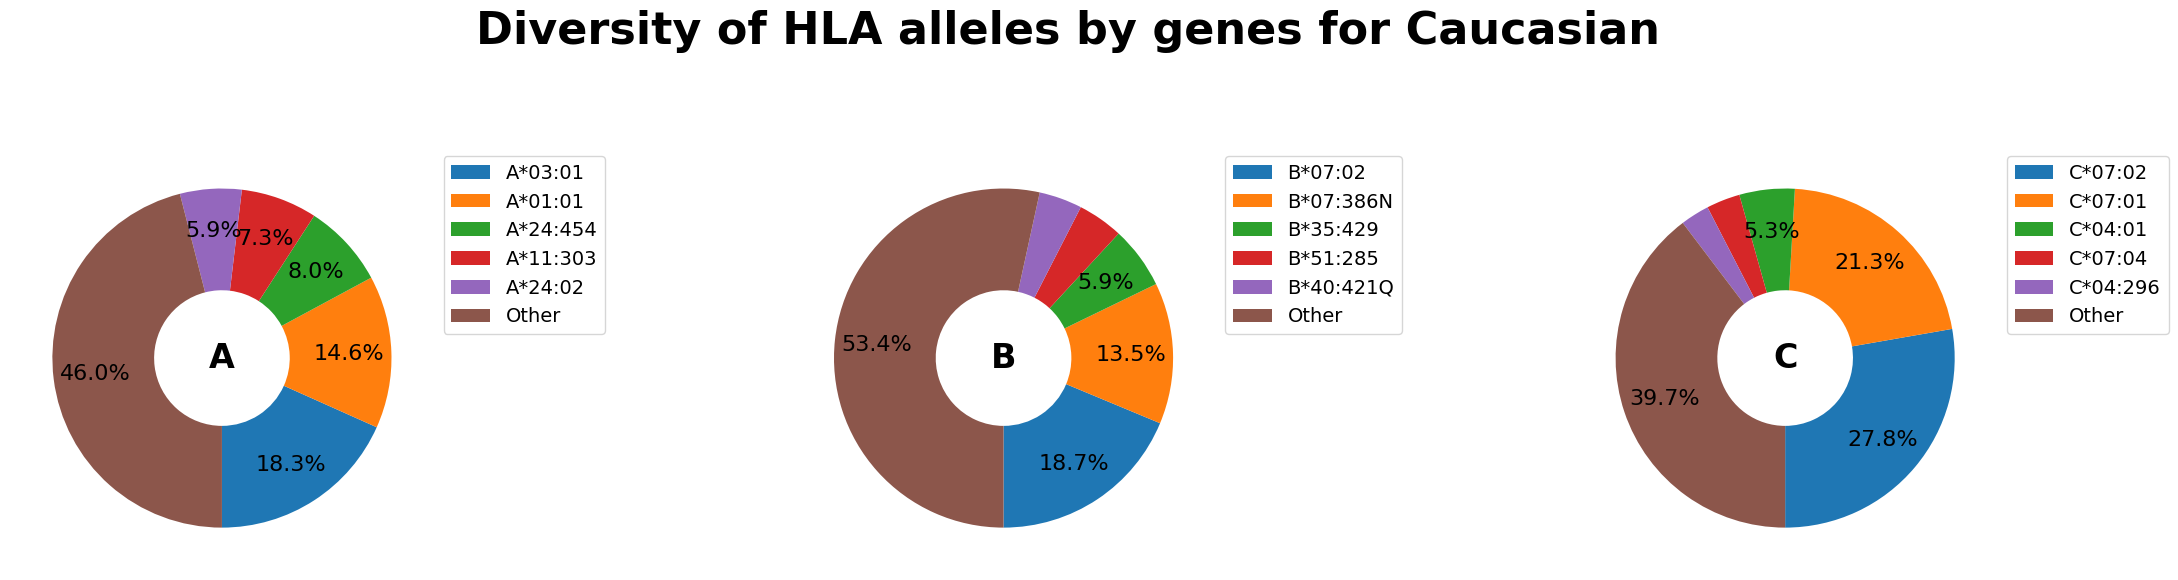

In [24]:
cohorts['C'].make_pie(1, 'Caucasian')

### Analysis of tests' results

In [25]:
fish_c = cohorts['C'].fisher_test_results
chi2_c = cohorts['C'].chi2_test_results

fish_aa = cohorts['AA'].fisher_test_results
chi2_aa = cohorts['AA'].chi2_test_results

fish_h = cohorts['H'].fisher_test_results
chi2_h = cohorts['H'].chi2_test_results

In [26]:
fish_c

,diagnosis,gene,allele,test,pval,OR,CI_lower,CI_upper,p_adj,p_adj_by_gene
0,CLE,A,A*03:01,fisher,0.537128,0.636364,0.179875,2.251332,0.743716,0.537128
1,CLE,B,B*07:02,fisher,0.738454,1.333333,0.343337,5.177932,0.849037,0.738454
2,CLE,B,B*35:15,fisher,0.082591,10.161290,0.489482,210.940933,0.268891,0.247773
3,CLE,B,B*40:01,fisher,0.672612,0.562500,0.090586,3.492873,0.849037,0.738454
4,CLE,C,C*07:02,fisher,0.754699,0.763636,0.215354,2.707822,0.849037,0.754699
...,...,...,...,...,...,...,...,...,...,...
162,SLE,DRB1,DRB1*12:01,fisher,0.703912,0.736559,0.162483,3.338932,0.992547,0.911392
163,SLE,DRB1,DRB1*16:02,fisher,0.192655,0.272000,0.049187,1.504144,0.804618,0.738511
164,SLE,DRB1,DRB1*08:01,fisher,0.619175,0.552000,0.076907,3.961993,0.982031,0.911392
165,SLE,DRB1,DRB1*13:04,fisher,0.619175,0.552000,0.076907,3.961993,0.982031,0.911392


In [27]:
# concatenation statistics for different populations
for p, d in zip(['C', 'H', 'AA'], [fish_c, fish_h, fish_aa]):
    d.insert(1, 'population', p)

stats = pd.concat([fish_c, fish_h, fish_aa])

In [28]:
stats

,diagnosis,population,gene,allele,test,pval,OR,CI_lower,CI_upper,p_adj,p_adj_by_gene
0,CLE,C,A,A*03:01,fisher,0.537128,0.636364,0.179875,2.251332,0.743716,0.537128
1,CLE,C,B,B*07:02,fisher,0.738454,1.333333,0.343337,5.177932,0.849037,0.738454
2,CLE,C,B,B*35:15,fisher,0.082591,10.161290,0.489482,210.940933,0.268891,0.247773
3,CLE,C,B,B*40:01,fisher,0.672612,0.562500,0.090586,3.492873,0.849037,0.738454
4,CLE,C,C,C*07:02,fisher,0.754699,0.763636,0.215354,2.707822,0.849037,0.754699
...,...,...,...,...,...,...,...,...,...,...,...
44,SLE,AA,DPB1,DPB1*677:01,fisher,1.000000,0.500000,0.043575,5.737298,1.000000,1.000000
45,SLE,AA,DPB1,DPB1*105:01,fisher,0.521053,0.252747,0.011212,5.697353,0.713794,1.000000
46,SLE,AA,DRA,DRA*01:02,fisher,0.642415,0.500000,0.068030,3.674838,0.713794,0.642415
47,SLE,AA,DRA,DRA*01:01,fisher,0.354360,0.266667,0.024342,2.921283,0.713794,0.531540


#### Identification of statistically significant alleles according to the Fisher test

In [29]:
stats[stats['p_adj_by_gene'] < 0.05]

,diagnosis,population,gene,allele,test,pval,OR,CI_lower,CI_upper,p_adj,p_adj_by_gene
9,CLE,C,DPB1,DPB1*04:01,fisher,0.005132,7.500000,1.798128,31.282529,0.090011,0.010263
16,CLE,C,DRB1,DRB1*15:01,fisher,0.010001,6.933333,1.719481,27.956753,0.090011,0.020002
77,SLE,C,C,C*07:04,fisher,0.001110,0.141292,0.038731,0.515438,0.157567,0.024412
53,MS,H,C,C*04:456Q,fisher,0.004559,14.285714,2.391957,85.319942,0.218854,0.027357
82,SLE,H,DQB1,DQB1*06:02,fisher,0.026923,33.000000,1.560253,697.963875,0.134615,0.026923


#### Preparing data for meta-analysis

In [30]:
data_for_plot = []
for diagnosis, sub in stats.groupby('diagnosis'):
    filtered_stats = sub.loc[(sub['CI_upper'] < 1) | (sub['CI_lower'] > 1)]
    alleles = pd.unique(filtered_stats['allele']).tolist()
    sub_data_for_plot = sub[sub['allele'].isin(alleles)]
    sub_data_for_plot = sub_data_for_plot[
    (sub_data_for_plot.duplicated(subset=['allele'], keep=False)) | 
    (sub_data_for_plot['p_adj_by_gene'] < 0.05)
]
    data_for_plot.append(sub_data_for_plot)

data_for_plot = pd.concat(data_for_plot).sort_values('diagnosis', ignore_index=True)
data_for_plot = data_for_plot[data_for_plot['diagnosis'] != 'H']
data_for_plot


,diagnosis,population,gene,allele,test,pval,OR,CI_lower,CI_upper,p_adj,p_adj_by_gene
0,CLE,C,DPB1,DPB1*04:01,fisher,0.005132,7.500000,1.798128,31.282529,0.090011,0.010263
1,CLE,C,DRB1,DRB1*15:01,fisher,0.010001,6.933333,1.719481,27.956753,0.090011,0.020002
2,CLE,H,DPB1,DPB1*04:01,fisher,0.107143,18.333333,0.535888,627.204405,0.214286,0.107143
3,CLE,AA,DPB1,DPB1*04:01,fisher,1.000000,1.440000,0.160091,12.952638,1.000000,1.000000
4,MS,C,DPB1,DPB1*04:01,fisher,1.000000,0.466667,0.012897,16.885540,1.000000,1.000000
5,MS,H,C,C*04:456Q,fisher,0.004559,14.285714,2.391957,85.319942,0.218854,0.027357
6,MS,H,DPB1,DPB1*04:01,fisher,0.041953,3.165217,1.050793,9.534326,0.503432,0.293669
7,SLE,C,C,C*07:04,fisher,0.001110,0.141292,0.038731,0.515438,0.157567,0.024412
8,SLE,C,DQB1,DQB1*06:02,fisher,0.345468,1.532164,0.691445,3.395099,0.865299,0.846637
9,SLE,H,DQB1,DQB1*06:02,fisher,0.026923,33.000000,1.560253,697.963875,0.134615,0.026923


In [31]:
alleles = data_for_plot['allele'].tolist()

In [32]:
# find significant alleles in all diseases and populations
data_for_plot_final = stats[stats['allele'].isin(alleles)]
data_for_plot_final = data_for_plot_final.sort_values(['diagnosis', 'gene'], ignore_index=True)
data_for_plot_final

,diagnosis,population,gene,allele,test,pval,OR,CI_lower,CI_upper,p_adj,p_adj_by_gene
0,CLE,C,DPB1,DPB1*04:01,fisher,0.005132,7.500000,1.798128,31.282529,0.090011,0.010263
1,CLE,H,DPB1,DPB1*04:01,fisher,0.107143,18.333333,0.535888,627.204405,0.214286,0.107143
2,CLE,AA,DPB1,DPB1*04:01,fisher,1.000000,1.440000,0.160091,12.952638,1.000000,1.000000
3,CLE,C,DQB1,DQB1*06:02,fisher,0.253430,3.166667,0.663424,15.115187,0.456175,0.413276
4,CLE,AA,DQB1,DQB1*06:02,fisher,0.689411,0.674074,0.152428,2.980929,1.000000,0.965175
5,CLE,C,DRB1,DRB1*15:01,fisher,0.010001,6.933333,1.719481,27.956753,0.090011,0.020002
6,H,H,DPB1,DPB1*04:01,fisher,0.143160,5.625000,0.661684,47.818342,0.900009,0.572641
7,H,H,DQB1,DQB1*06:02,fisher,0.657821,1.375000,0.245502,7.701062,1.000000,1.000000
8,H,H,DRB1,DRB1*15:01,fisher,1.000000,0.931818,0.172565,5.031651,1.000000,1.000000
9,MS,H,C,C*04:456Q,fisher,0.004559,14.285714,2.391957,85.319942,0.218854,0.027357


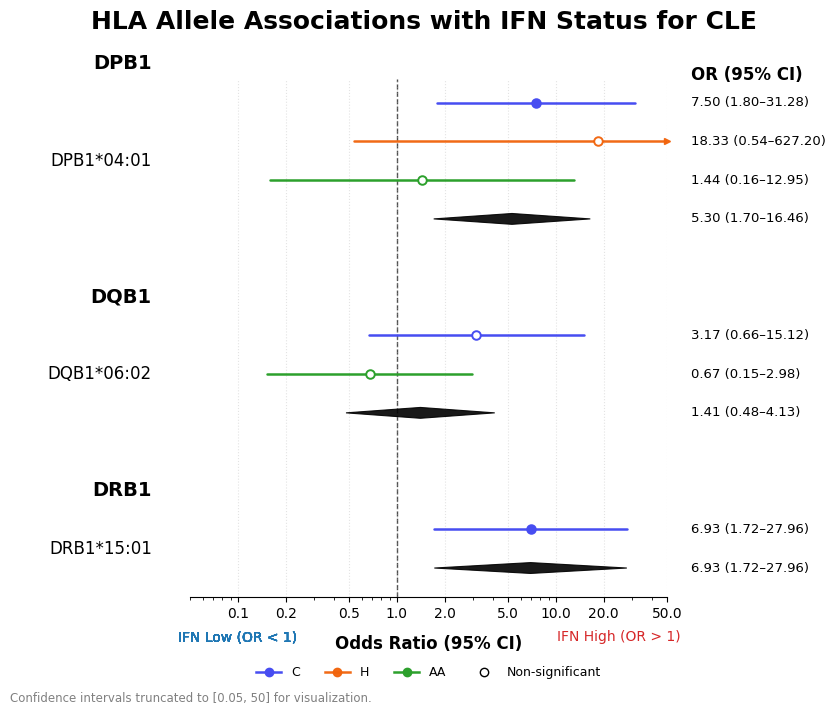

In [33]:
HLA_forest_plot.plot_forest(data_for_plot_final[data_for_plot_final['diagnosis'] == 'CLE'], diag='CLE')

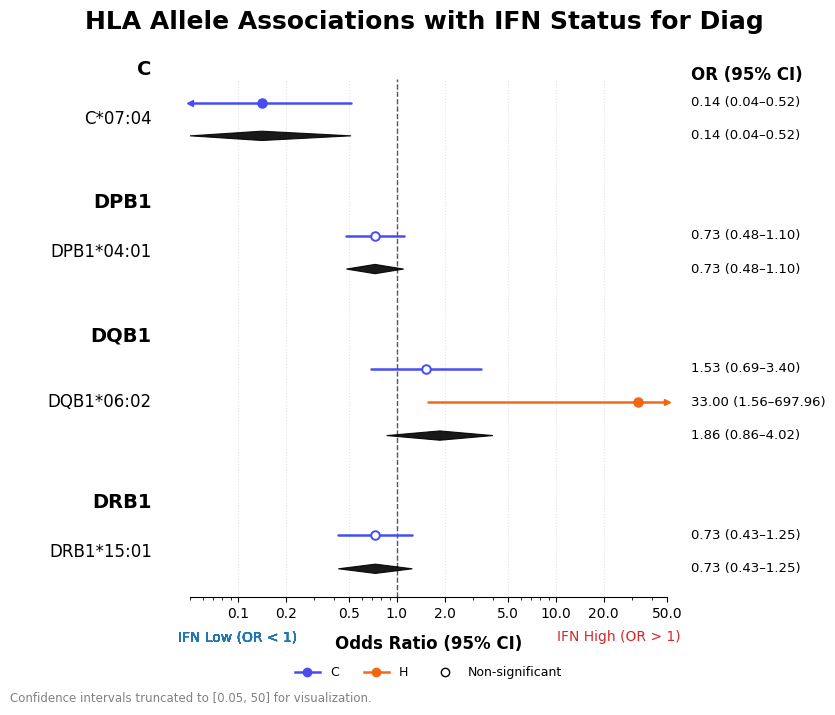

In [34]:
HLA_forest_plot.plot_forest(data_for_plot_final[data_for_plot_final['diagnosis'] == 'SLE'])

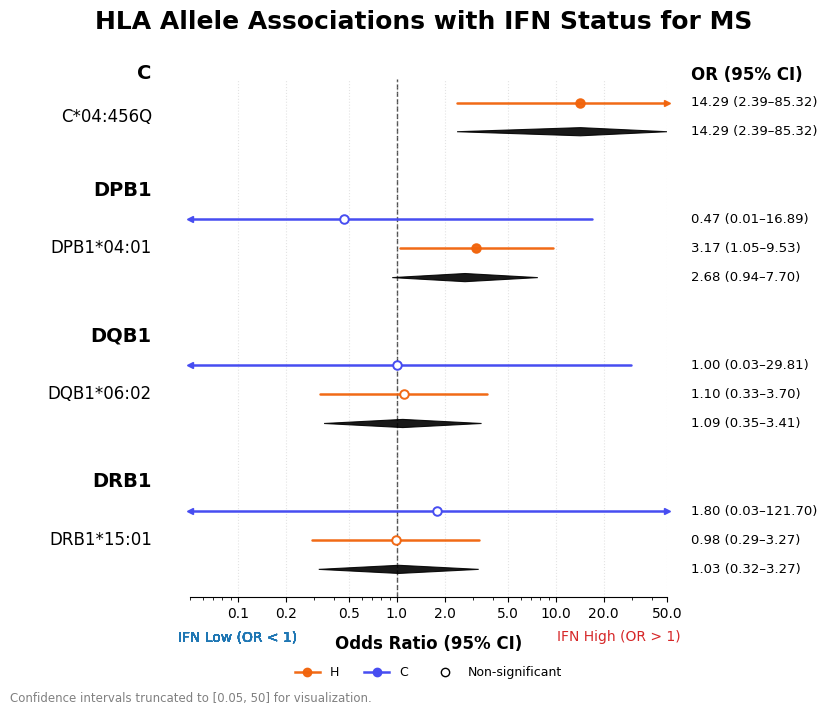

In [35]:
HLA_forest_plot.plot_forest(data_for_plot_final[data_for_plot_final['diagnosis'] == 'MS'], 'MS')

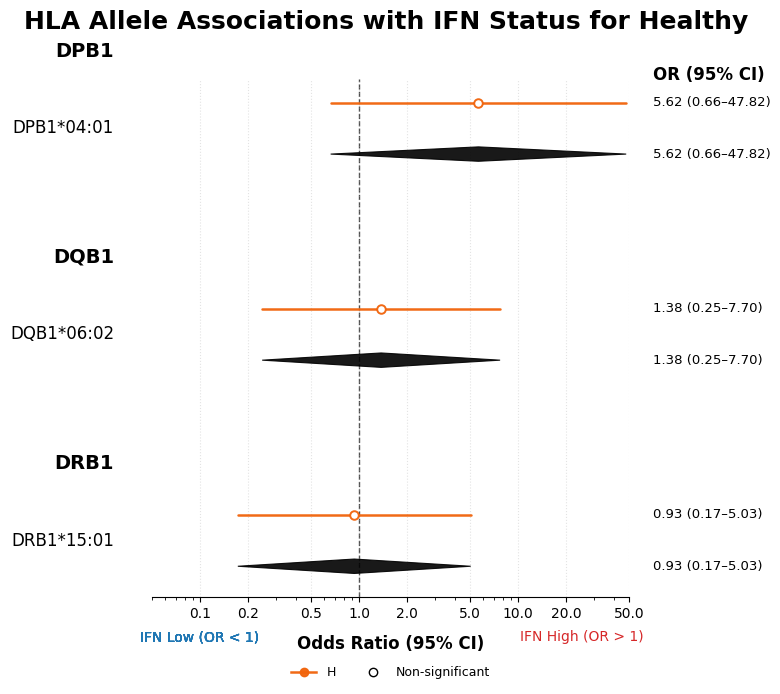

In [36]:
HLA_forest_plot.plot_forest(data_for_plot_final[data_for_plot_final['diagnosis'] == 'H'], 'Healthy')